Using device:cuda
Epoch [10/50], Train Loss: 0.6865, Val Loss: 0.6879, Acc: 0.5800
Epoch [20/50], Train Loss: 0.6776, Val Loss: 0.6843, Acc: 0.5550
Epoch [30/50], Train Loss: 0.6674, Val Loss: 0.6833, Acc: 0.5500
Epoch [40/50], Train Loss: 0.6575, Val Loss: 0.6829, Acc: 0.5550
Epoch [50/50], Train Loss: 0.6479, Val Loss: 0.6837, Acc: 0.5450
训练完成！


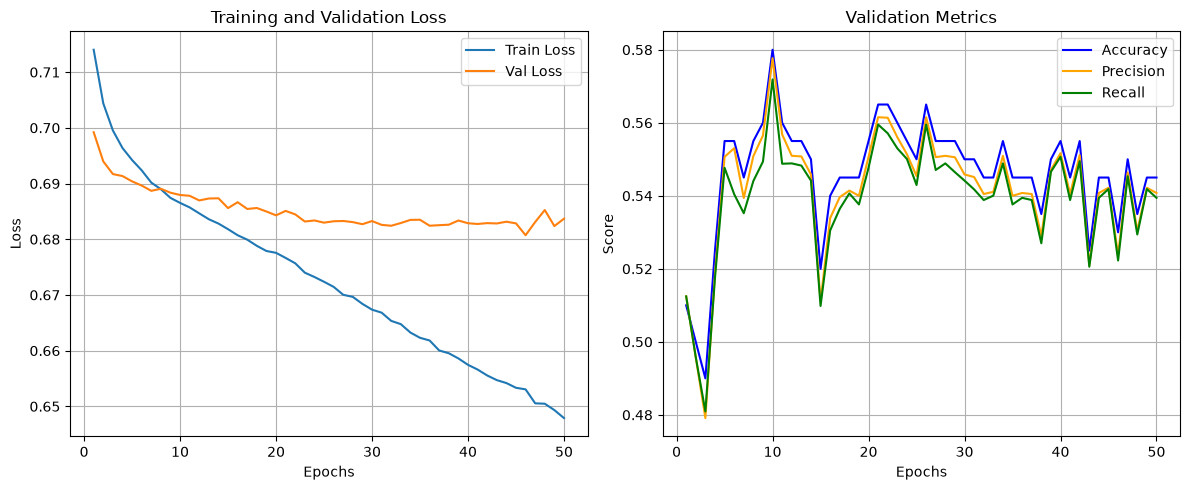

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
import matplotlib.pyplot as plt
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
INPUT_FEATURES = 10
NUM_CLASSES = 2
TRAIN_RATIO = 0.8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device:{device}")
class RandomDataset(Dataset):
    def __init__(self,num_samples=1000,input_dim=10,num_classes=2):
        self.X = torch.randn(num_samples,input_dim)
        self.y = torch.randint(0,num_classes,(num_samples,))
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]
full_dataset = RandomDataset(num_samples=1000,input_dim=INPUT_FEATURES,num_classes=NUM_CLASSES) 
train_size = int(TRAIN_RATIO * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset,val_dataset = random_split(full_dataset,[train_size,val_size])
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
class SimpleNN(nn.Module):
    def __init__(self,input_dim,hidden_dim,num_classes):
        super(SimpleNN,self).__init__()
        self.fc1 = nn.Linear(input_dim,hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim,num_classes)
    def forward(self,x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out
model = SimpleNN(input_dim=INPUT_FEATURES,hidden_dim=32,num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=LEARNING_RATE)
history = {
    'train_loss':[],
    'val_loss':[],
    'val_accuracy':[],
    'val_precision':[],
    'val_recall':[]
}
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    for inputs,labels in train_loader:
        inputs,labels = inputs.to(device),labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
    epoch_train_loss = running_train_loss / len(train_dataset)
    history['train_loss'].append(epoch_train_loss)
    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs,labels in val_loader:
            inputs,labels = inputs.to(device),labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs,labels)
            running_val_loss += loss.item() * inputs.size(0)
            _,predicted = torch.max(outputs.data,1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_val_loss = running_val_loss / len(val_dataset)
    accuracy = accuracy_score(all_labels,all_preds)
    precision = precision_score(all_labels,all_preds,average='macro',zero_division=0)
    recall = recall_score(all_labels,all_preds,average='macro',zero_division=0)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(accuracy)
    history['val_precision'].append(precision)
    history['val_recall'].append(recall)
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Acc: {accuracy:.4f}")
print("训练完成！")
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1,EPOCHS+1),history['train_loss'],label='Train Loss')
plt.plot(range(1,EPOCHS+1),history['val_loss'],label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,EPOCHS+1),history['val_accuracy'],label='Accuracy',color='blue')
plt.plot(range(1,EPOCHS+1),history['val_precision'],label='Precision',color='orange')
plt.plot(range(1,EPOCHS+1),history['val_recall'],label='Recall',color='green')
plt.title('Validation Metrics')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def binary_search(arr,target):
    lo,hi = 0,len(arr) - 1
    while lo <= hi:
        mid = (lo+hi) // 2
        assert 0 <= lo <= mid <= hi < len(arr), f"索引越界: lo={lo}, mid={mid}, hi={hi}"
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1

In [7]:
def get_value_lbyl(d,key):
    if key in d and isinstance(d[key],int):
        return d[key]
    return 0
def get_value_eafp(d,key):
    try:
        return int(d[key])
    except (KeyError,TypeError,ValueError):
        return 0
import os
if os.path.exists('out.txt') and os.path.isfile('out.txt'):
    open('out.txt','w').write('hi')

In [16]:
import numpy as np
a = np.array([1,2,3])
zeros = np.zeros((3,4))
ones = np.ones((2,3))
arange = np.arange(0,10,2)
linspace = np.linspace(0,1,5)
random = np.random.rand(3,3)
randn = np.random.randn(3,3)
print(a)

[1 2 3]


In [22]:
arr = np.array([[1,2,3],[4,5,6]])
print(arr)
print(arr.shape)
print(arr.ndim)
print(arr.size)
print(arr.dtype)

[[1 2 3]
 [4 5 6]]
(2, 3)
2
6
int64


In [26]:
arr = np.array([[1,2,3],
                [4,5,6],
                [7,8,9]])
print(arr[0])
print(arr[:,1])
print(arr[0:2,1:])
print(arr[arr > 5])

[1 2 3]
[2 5 8]
[[2 3]
 [5 6]]
[6 7 8 9]


In [31]:
arr = np.arange(12)
arr.reshape(3,4)
arr.reshape(-1,3)
arr.flatten()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [37]:
import numpy as np
I = np.eye(5)
print("1. 5×5 单位矩阵：")
print(I)

1. 5×5 单位矩阵：
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [40]:
arr = np.arange(100).reshape(10,10)
print("\n2. reshape 后形状：", arr.shape)
print(arr)
evens = arr[arr % 2 == 0]
print("\n3. 所有偶数元素（一维数组）：")
print(evens)
print("偶数元素个数：", evens.size)


2. reshape 后形状： (10, 10)
[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]

3. 所有偶数元素（一维数组）：
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98]
偶数元素个数： 50


In [42]:
A = np.random.randn(3,4)
B = np.random.rand(4,2)
result = A @ B
print(result.shape)
print(result)

(3, 2)
[[ 1.62369169  1.60476073]
 [-0.45763438  0.06200145]
 [ 1.19552901  0.58299814]]


In [46]:
x = np.array([1,2,3,4,5])
print(np.mean(x))
print(np.std(x))
print(np.max(x))
print(np.min(x))

3.0
1.4142135623730951
5
1


In [49]:
arr = np.arange(10)
print(arr[:3])
print(arr[2:6])
print(arr[3::2])
print(arr[::-1])

[0 1 2]
[2 3 4 5]
[3 5 7 9]
[9 8 7 6 5 4 3 2 1 0]


In [51]:
arr = np.arange(20).reshape(4,5)
print(arr)
print(arr[1,:])
print(arr[:,2])
print(arr[:2,:3])
print(arr[0::2,1:4])

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
[5 6 7 8 9]
[ 2  7 12 17]
[[0 1 2]
 [5 6 7]]
[[ 1  2  3]
 [11 12 13]]


In [53]:
arr = np.array([3,-1,7,-5,0,9,2])
mask_pos = arr > 0
print(arr[mask_pos])
arr_copy = arr.copy()
arr_copy[arr_copy < 0] = 0
print(arr_copy)
print(arr[arr % 3 == 0])

[3 7 9 2]
[3 0 7 0 0 9 2]
[3 0 9]


In [55]:
arr = np.arange(100,110)
print(arr[[0,3,5,9]])
print(arr[[4,4,2,2]])
M = np.arange(12).reshape(4,3)
print(M)
print(M[[0,2,3],[1,0,2]])

[100 103 105 109]
[104 104 102 102]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[ 1  6 11]
